In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42

print("Imports successful.")
print("LightGBM:", lgb.__version__)

Imports successful.
LightGBM: 4.7.0


In [3]:
def aggregate_bureau(bureau):
    b = bureau.copy()

    num_agg = b.groupby("SK_ID_CURR").agg({
        "DAYS_CREDIT": ["count", "mean", "min", "max"],
        "CREDIT_DAY_OVERDUE": ["mean", "max"],
        "AMT_CREDIT_SUM": ["sum", "mean", "max"],
        "AMT_CREDIT_SUM_DEBT": ["sum", "mean"],
        "AMT_CREDIT_SUM_OVERDUE": ["sum", "max"],
        "CNT_CREDIT_PROLONG": ["sum"],
    })

    num_agg.columns = [
        "BURO_" + "_".join(c).upper()
        for c in num_agg.columns
    ]

    active = (
        b[b["CREDIT_ACTIVE"] == "Active"]
        .groupby("SK_ID_CURR")
        .size()
    )

    closed = (
        b[b["CREDIT_ACTIVE"] == "Closed"]
        .groupby("SK_ID_CURR")
        .size()
    )

    num_agg["BURO_ACTIVE_COUNT"] = active
    num_agg["BURO_CLOSED_COUNT"] = closed

    num_agg[
        ["BURO_ACTIVE_COUNT", "BURO_CLOSED_COUNT"]
    ] = num_agg[
        ["BURO_ACTIVE_COUNT", "BURO_CLOSED_COUNT"]
    ].fillna(0)

    return num_agg.reset_index()

def aggregate_previous(previous):
    p = previous.copy()

    # Numerical features
    num_agg = p.groupby("SK_ID_CURR").agg({
        "SK_ID_PREV": ["count"],
        "AMT_ANNUITY": ["mean", "max"],
        "AMT_APPLICATION": ["mean", "max"],
        "AMT_CREDIT": ["mean", "max"],
        "AMT_DOWN_PAYMENT": ["mean"],
        "AMT_GOODS_PRICE": ["mean"],
        "DAYS_DECISION": ["mean", "min", "max"],
    })

    num_agg.columns = [
        "PREV_" + "_".join(c).upper()
        for c in num_agg.columns
    ]

    # Contract status counts
    status = pd.crosstab(
        p["SK_ID_CURR"],
        p["NAME_CONTRACT_STATUS"]
    )

    for col in [
        "Approved",
        "Canceled",
        "Refused",
        "Unused offer"
    ]:
        if col not in status.columns:
            status[col] = 0

    status = status[
        ["Approved", "Canceled", "Refused", "Unused offer"]
    ]

    status.columns = [
        "PREV_STATUS_" + col.upper().replace(" ", "_")
        for col in status.columns
    ]

    # Approval / refusal / cancellation rates
    total = status.sum(axis=1)

    status["PREV_APPROVAL_RATE"] = (
        status["PREV_STATUS_APPROVED"] / total
    )

    status["PREV_REFUSAL_RATE"] = (
        status["PREV_STATUS_REFUSED"] / total
    )

    status["PREV_CANCELLATION_RATE"] = (
        status["PREV_STATUS_CANCELED"] / total
    )

    # Combine everything
    result = num_agg.join(status, how="left")

    return result.reset_index()

def add_ratios(df):
    df = df.copy()

    df["CREDIT_INCOME_RATIO"] = (
        df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    )

    df["ANNUITY_INCOME_RATIO"] = (
        df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    )

    df["CREDIT_TERM"] = (
        df["AMT_ANNUITY"] / df["AMT_CREDIT"]
    )

    df["GOODS_CREDIT_RATIO"] = (
        df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]
    )

    df["INCOME_PER_PERSON"] = (
        df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
    )

    return df


def prep_for_lgbm(df):
    df = df.copy()

    # Handle DAYS_EMPLOYED anomaly
    df["DAYS_EMPLOYED_ANOM"] = (
        df["DAYS_EMPLOYED"] == 365243
    ).astype("int8")

    df["DAYS_EMPLOYED"] = (
        df["DAYS_EMPLOYED"]
        .replace(365243, np.nan)
    )

    # Convert categorical columns to pandas category
    for col in df.select_dtypes(exclude="number").columns:
        df[col] = df[col].astype("category")

    # Reduce float64 memory usage
    for col in df.select_dtypes(include="float64").columns:
        df[col] = df[col].astype("float32")

    return df


print("prep_for_lgbm is ready.")

prep_for_lgbm is ready.


In [4]:
app = pd.read_csv("../data/raw/application_train.csv")

bureau = pd.read_csv("../data/raw/bureau.csv")
buro_agg = aggregate_bureau(bureau)
del bureau

previous = pd.read_csv("../data/raw/previous_application.csv")
prev_agg = aggregate_previous(previous)
del previous

app_full = (
    app
    .merge(buro_agg, on="SK_ID_CURR", how="left")
    .merge(prev_agg, on="SK_ID_CURR", how="left")
)

print("Final joined shape:", app_full.shape)

Final joined shape: (307511, 157)


In [5]:
X_full = app_full.drop(columns=["TARGET", "SK_ID_CURR"])
y_full = app_full["TARGET"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_full
)

print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)
print("Development default rate:", round(y_dev.mean(), 4))
print("Test default rate:", round(y_test.mean(), 4))

Development set: (246008, 155)
Test set: (61503, 155)
Development default rate: 0.0807
Test default rate: 0.0807


In [6]:
X_dev = prep_for_lgbm(add_ratios(X_dev))

X_dev["NO_BUREAU_HISTORY"] = (
    X_dev["BURO_DAYS_CREDIT_COUNT"].isna().astype("int8")
)

X_dev["NO_PREV_HISTORY"] = (
    X_dev["PREV_SK_ID_PREV_COUNT"].isna().astype("int8")
)

X_dev["PREV_CREDIT_APPLICATION_RATIO"] = (
    X_dev["PREV_AMT_CREDIT_MEAN"] /
    X_dev["PREV_AMT_APPLICATION_MEAN"]
).replace([np.inf, -np.inf], np.nan)

print("Shape:", X_dev.shape)
print(
    "Infinite values:",
    np.isinf(X_dev.select_dtypes("number")).sum().sum()
)

Shape: (246008, 164)
Infinite values: 0


/tmp/ipykernel_10669/3108263113.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_dev["NO_BUREAU_HISTORY"] = (
/tmp/ipykernel_10669/3108263113.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_dev["NO_PREV_HISTORY"] = (
/tmp/ipykernel_10669/3108263113.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fram

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

print("Training set:", X_tr.shape)
print("Validation set:", X_val.shape)
print("Training default rate:", round(y_tr.mean(), 4))
print("Validation default rate:", round(y_val.mean(), 4))

Training set: (184506, 164)
Validation set: (61502, 164)
Training default rate: 0.0807
Validation default rate: 0.0807


In [8]:
final = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    n_estimators=300,
    learning_rate=0.05,
    verbose=-1,
    n_jobs=2
).fit(X_tr, y_tr)

probs = final.predict_proba(X_val)[:, 1]

err = X_val.copy()
err["actual"] = y_val.values
err["prob"] = probs

print("Model fitted and predictions generated.")

Model fitted and predictions generated.


In [9]:
def group_auc(df, col, min_n=1000):
    rows = []

    for val, g in df.groupby(col, observed=True):
        if len(g) < min_n or g["actual"].nunique() < 2:
            continue

        rows.append({
            "group": val,
            "n": len(g),
            "default_rate": g["actual"].mean(),
            "auc": roc_auc_score(g["actual"], g["prob"]),
            "mean_predicted": g["prob"].mean(),
        })

    return pd.DataFrame(rows).sort_values("auc")

print("group_auc ready.")

group_auc ready.


In [10]:
print(group_auc(err, "NO_BUREAU_HISTORY"))

   group      n  default_rate       auc  mean_predicted
1      1   8903      0.101090  0.751485        0.101204
0      0  52599      0.077283  0.771250        0.077155


In [11]:
print(group_auc(err, "NAME_EDUCATION_TYPE"))

                           group      n  default_rate       auc  \
2  Secondary / secondary special  43758      0.089744  0.762147   
1              Incomplete higher   2065      0.070702  0.771406   
0               Higher education  14888      0.054272  0.776501   

   mean_predicted  
2        0.088700  
1        0.085403  
0        0.055015  


In [12]:
print(group_auc(err, "CODE_GENDER"))

  group      n  default_rate       auc  mean_predicted
1     M  20972      0.101087  0.762828        0.098638
0     F  40529      0.070197  0.766533        0.071319


In [13]:
print(group_auc(err, "NAME_INCOME_TYPE"))

                  group      n  default_rate       auc  mean_predicted
1             Pensioner  11018      0.052187  0.745875        0.054538
0  Commercial associate  14349      0.075963  0.759594        0.077626
3               Working  31761      0.095274  0.767482        0.093888
2         State servant   4360      0.062156  0.776330        0.059993


In [14]:
print(group_auc(err, "DAYS_EMPLOYED_ANOM"))

   group      n  default_rate       auc  mean_predicted
1      1  11021      0.052445  0.747085        0.054578
0      0  50481      0.086904  0.768572        0.086326


In [15]:
err["age_band"] = pd.cut(
    err["DAYS_BIRTH"] / -365,
    [20, 30, 40, 50, 60, 70]
)

print(group_auc(err, "age_band"))

      group      n  default_rate       auc  mean_predicted
4  (60, 70]   7008      0.048373  0.729435        0.048616
0  (20, 30]   8936      0.113026  0.755832        0.118705
2  (40, 50]  15479      0.075457  0.761471        0.076245
3  (50, 60]  13596      0.061489  0.762838        0.062946
1  (30, 40]  16483      0.097798  0.768861        0.092328


In [17]:
import matplotlib.pyplot as plt

print("Matplotlib ready.")

Matplotlib ready.


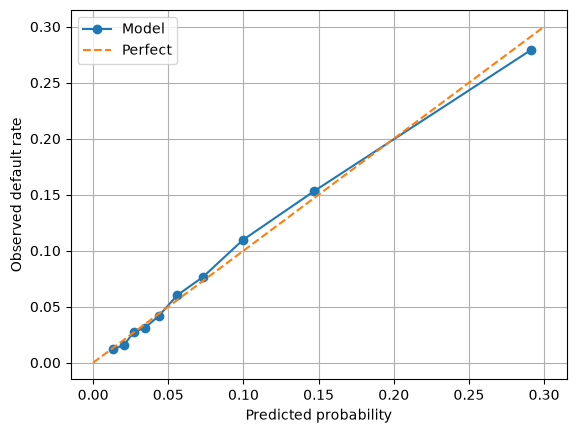

In [18]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val,
    probs,
    n_bins=10,
    strategy="quantile"
)

plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 0.3], [0, 0.3], "--", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/figures/calibration.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [19]:
false_neg = err[
    (err["prob"] < 0.05) &
    (err["actual"] == 1)
]

false_pos = err[
    (err["prob"] > 0.5) &
    (err["actual"] == 0)
]

print(len(false_neg), "defaults the model was confident about")
print(len(false_pos), "good customers flagged as high risk")

819 defaults the model was confident about
151 good customers flagged as high risk


In [20]:
print("False negatives — key characteristics:")
print(
    false_neg[
        [
            "AMT_INCOME_TOTAL",
            "DAYS_BIRTH",
            "NAME_EDUCATION_TYPE",
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3",
        ]
    ].describe(include="all")
)

False negatives — key characteristics:
        AMT_INCOME_TOTAL    DAYS_BIRTH            NAME_EDUCATION_TYPE  \
count         819.000000    819.000000                            819   
unique               NaN           NaN                              4   
top                  NaN           NaN  Secondary / secondary special   
freq                 NaN           NaN                            576   
mean       172753.859375 -17102.520147                            NaN   
std         97169.296875   4194.712875                            NaN   
min         27000.000000 -25142.000000                            NaN   
25%        112500.000000 -20475.000000                            NaN   
50%        157500.000000 -17124.000000                            NaN   
75%        225000.000000 -13807.500000                            NaN   
max        832500.000000  -7973.000000                            NaN   

        EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  
count     373.000000    816.00000

In [21]:
print("False positives — key characteristics:")
print(
    false_pos[
        [
            "AMT_INCOME_TOTAL",
            "DAYS_BIRTH",
            "NAME_EDUCATION_TYPE",
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3",
        ]
    ].describe(include="all")
)

False positives — key characteristics:
        AMT_INCOME_TOTAL    DAYS_BIRTH            NAME_EDUCATION_TYPE  \
count         151.000000    151.000000                            151   
unique               NaN           NaN                              4   
top                  NaN           NaN  Secondary / secondary special   
freq                 NaN           NaN                            137   
mean       152347.703125 -14038.854305                            NaN   
std         64457.714844   3747.936420                            NaN   
min         29700.000000 -23302.000000                            NaN   
25%        112500.000000 -16438.000000                            NaN   
50%        135000.000000 -13675.000000                            NaN   
75%        180000.000000 -10950.000000                            NaN   
max        450000.000000  -8478.000000                            NaN   

        EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  
count      55.000000    151.00000

In [22]:
for grp in [0, 1]:
    sub = err[err["NO_BUREAU_HISTORY"] == grp]
    thresh = err["prob"].quantile(0.80)

    rejected = sub["prob"] >= thresh

    print(
        f"group={grp}: rejected {rejected.mean():.1%}, "
        f"defaults caught "
        f"{sub.loc[rejected, 'actual'].sum() / sub['actual'].sum():.1%}"
    )

group=0: rejected 18.6%, defaults caught 52.2%
group=1: rejected 28.3%, defaults caught 59.7%


In [23]:
from sklearn.metrics import brier_score_loss

print("Brier:", brier_score_loss(y_val, probs))
print("Mean predicted:", probs.mean(), "| Actual rate:", y_val.mean())

Brier: 0.06727420438709207
Mean predicted: 0.08063646466350961 | Actual rate: 0.08072908198107379


In [24]:
X_test_prep = prep_for_lgbm(add_ratios(X_test))

X_test_prep["NO_BUREAU_HISTORY"] = (
    X_test_prep["BURO_DAYS_CREDIT_COUNT"]
    .isna()
    .astype("int8")
)

X_test_prep["NO_PREV_HISTORY"] = (
    X_test_prep["PREV_SK_ID_PREV_COUNT"]
    .isna()
    .astype("int8")
)

X_test_prep["PREV_CREDIT_APPLICATION_RATIO"] = (
    X_test_prep["PREV_AMT_CREDIT_MEAN"]
    / X_test_prep["PREV_AMT_APPLICATION_MEAN"]
).replace([np.inf, -np.inf], np.nan)

X_test_prep = X_test_prep[X_dev.columns]

print("Test prepared:", X_test_prep.shape)
print("Columns match:", X_test_prep.columns.equals(X_dev.columns))
print(
    "Infinite values:",
    np.isinf(X_test_prep.select_dtypes("number")).sum().sum()
)

Test prepared: (61503, 164)
Columns match: True
Infinite values: 0


/tmp/ipykernel_10669/3230928885.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_prep["NO_BUREAU_HISTORY"] = (
/tmp/ipykernel_10669/3230928885.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_prep["NO_PREV_HISTORY"] = (
/tmp/ipykernel_10669/3230928885.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `new

In [25]:
final_model = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    n_estimators=300,
    learning_rate=0.05,
    verbose=-1,
    n_jobs=2
)

final_model.fit(X_dev, y_dev)

print("Final model trained on full development set.")

Final model trained on full development set.


In [26]:
test_probs = final_model.predict_proba(X_test_prep)[:, 1]

test_auc = roc_auc_score(y_test, test_probs)

print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.7764


## Error Analysis Findings

### Group performance

The model performs reasonably consistently across most groups, but some groups are noticeably harder to rank than others.

The clearest difference is applicants with no bureau history. Their AUC is 0.7515, compared with 0.7713 for applicants with bureau history. However, their mean predicted risk (10.12%) is almost identical to their actual default rate (10.11%). This suggests that the model is not simply over-penalising thin-file applicants; the group is genuinely riskier, while the model has less ability to distinguish risk within the group.

Using one global cutoff at the 80th percentile, 28.3% of applicants with no bureau history were rejected, compared with 18.6% of applicants with bureau history. The model caught 59.7% of defaults in the thin-file group versus 52.2% in the group with bureau history. This shows that the AUC gap translates into a meaningful difference in business outcomes and would justify further policy analysis for thin-file applicants.

Age also shows a notable difference. Applicants aged 60–70 have the lowest group AUC at 0.7294. Pensioners and applicants with anomalous employment values also have relatively low AUCs, suggesting these groups overlap and are harder for the model to rank accurately.

Gender performance is very similar: AUC is 0.7628 for males and 0.7665 for females.

Among income groups, pensioners have the lowest AUC at 0.7459, while state servants have the highest at 0.7763.

### Calibration

The calibration curve stays reasonably close to the perfect-calibration line across most probability ranges.

The Brier score is 0.06727. The mean predicted probability is 0.08064, compared with an actual validation default rate of 0.08073. The close agreement between these two values indicates that the model is well aligned with the overall observed default rate, although the calibration curve still shows some local deviations.

### Confident errors

The model produced 819 confident false negatives: applicants who actually defaulted but received a predicted probability below 5%.

It also produced 151 confident false positives: applicants who did not default but received a predicted probability above 50%.

The false negatives do not show an obvious single characteristic that explains the errors. Their median income was 157,500, while the median available external scores were approximately 0.618 for EXT_SOURCE_2 and 0.600 for EXT_SOURCE_3.

The false positives had substantially lower external scores, with median values of 0.202 for EXT_SOURCE_1, 0.127 for EXT_SOURCE_2, and 0.151 for EXT_SOURCE_3. This suggests that the model was responding to genuine risk signals, but those signals did not always correspond to an actual default. The model therefore inherits some of the limitations and errors present in the external data.

### Overall conclusion

The model is reasonably strong and reasonably calibrated, but performance is not uniform across all groups.

Thin-file applicants have a higher underlying default rate and are rejected more often under a common threshold, while the model is also less able to rank risk within that group. Older applicants, particularly the 60–70 age band, are another weak-performing segment.

Before deployment, I would investigate group-specific performance further, especially for applicants with no bureau history and older applicants. I would also evaluate threshold and approval policies rather than relying on AUC alone.